# 04 — EDA: Trust-Level Performance

**Goal:** Move from the national picture (Notebook 03) to individual NHS trust performance. Identify which trusts consistently outperform or underperform, how performance varies by region and size, and examine the local picture for Huntingdonshire.

**Data source:** `data/processed/quarterly_by_provider.csv` (5,062 rows, ~200 trusts × 24 quarters)

**This notebook focuses on Type 1 trusts only** — those that run a major A&E department. The 4-hour standard only applies to Type 1. Mixing in Type 2/3 trusts would distort comparisons.

**Outputs:** Charts saved to `outputs/figures/`

**Data coverage note:** 92.1% of Type 1 trust-quarters have valid `pct_4hr_type1` data. Coverage is consistent at ~89% for 2019-20 through 2022-23, then improves to 97–100% from 2023-24 onwards. The ~11% missing reflects trusts that had Type 1 attendances but did not submit percentage data for those quarters — a known quirk of NHS reporting. The analysis filters to trusts with sufficient data where noted.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv(
    "../data/processed/quarterly_by_provider.csv"
)

# Type 1 trusts only
type1 = df[df["type1_attendances"] > 0].copy()

COMPLETE_FYS = ["2019-20", "2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]
REGION_SHORT = {
    "NHS England East Of England":          "East of England",
    "NHS England London":                   "London",
    "NHS England Midlands":                 "Midlands",
    "NHS England North East And Yorkshire": "NE & Yorkshire",
    "NHS England North West":               "North West",
    "NHS England South East":               "South East",
    "NHS England South West":               "South West",
}
type1["region_short"] = type1["region"].map(REGION_SHORT)

REGION_COLOURS = {
    "East of England":  "#4878CF",
    "London":           "#D65F5F",
    "Midlands":         "#6ACC65",
    "NE & Yorkshire":   "#B47CC7",
    "North West":       "#C4AD66",
    "South East":       "#77BEDB",
    "South West":       "#F7910A",
}

FIG_DIR = "../outputs/figures/"

print(f"Type 1 trust-quarters: {len(type1):,}")
print(f"Unique Type 1 trusts:   {type1['code'].nunique()}")
print(f"Valid pct_4hr_type1:    {type1['pct_4hr_type1'].notna().sum():,} ({type1['pct_4hr_type1'].notna().mean():.1%})")

Type 1 trust-quarters: 3,014
Unique Type 1 trusts:   136
Valid pct_4hr_type1:    2,776 (92.1%)


---
## Part 1 — How Performance Is Distributed Across Trusts

Rather than just looking at the England average (which Notebook 03 covered), we now look at the *distribution* of trust performance. The national average hides a great deal of variation — some trusts consistently outperform while others consistently fall well below.

Box plots by financial year show the median, interquartile range, and outliers for each year. This tells us:
- Whether the whole distribution shifted down, or just the tail got worse
- How much variation exists across trusts in a given year
- Whether the spread widened or narrowed over time

**2020-21 is included but annotated** — performance was artificially elevated because attendance volumes collapsed. The box plot for that year shows higher medians but shouldn't be interpreted as genuine improvement.

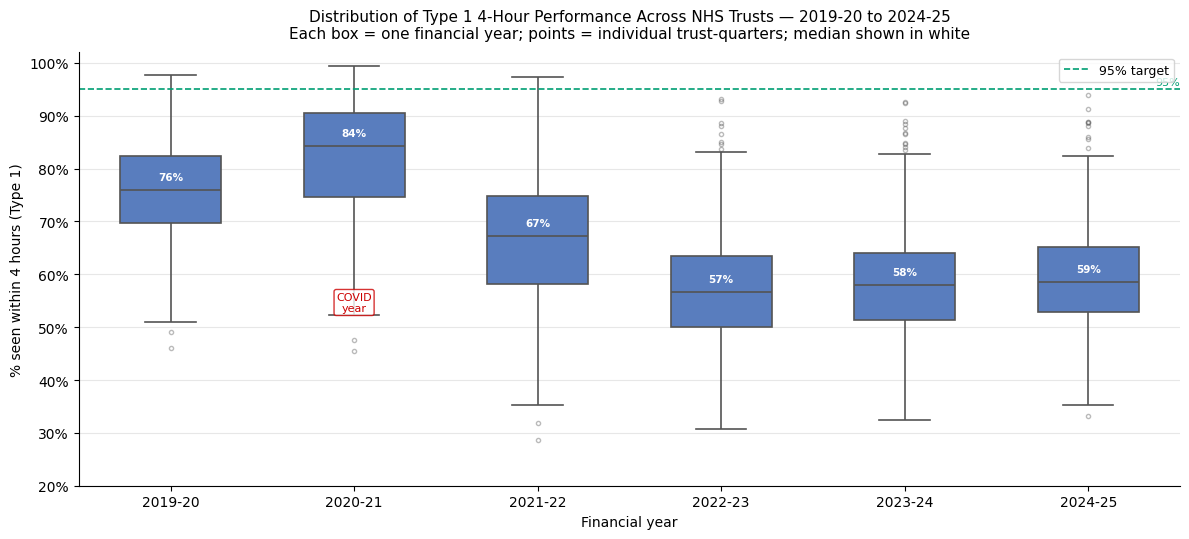

Saved: 04_01_performance_distribution.png

Median and IQR by financial year:
  Year          Median        Q1        Q3   Below 75%
  2019-20        76.0%     69.8%     82.4%       45.6%
  2020-21        84.3%     74.5%     90.4%       27.1%
  2021-22        67.2%     58.2%     74.8%       75.1%
  2022-23        56.6%     50.1%     63.5%       93.9%
  2023-24        58.0%     51.4%     64.1%       93.7%
  2024-25        58.6%     52.8%     65.1%       95.1%


In [2]:
plot_data = type1[type1["financial_year"].isin(COMPLETE_FYS)].dropna(subset=["pct_4hr_type1"])

fig, ax = plt.subplots(figsize=(12, 5.5))

bp = sns.boxplot(
    data=plot_data,
    x="financial_year", y="pct_4hr_type1",
    order=COMPLETE_FYS,
    ax=ax,
    color="#4878CF",
    width=0.55,
    fliersize=3,
    flierprops=dict(marker="o", alpha=0.4),
    linewidth=1.2,
)

# 95% target
ax.axhline(0.95, color="#009E73", linestyle="--", linewidth=1.2, label="95% target")
ax.text(5.5, 0.954, "95%", color="#009E73", fontsize=8, ha="right", va="bottom")

# COVID annotation
ax.text(1.0, 0.53, "COVID\nyear", color="#CC0000", fontsize=8, ha="center",
        bbox=dict(facecolor="white", edgecolor="#CC0000", boxstyle="round,pad=0.2", alpha=0.8))

# Annotate medians
for i, fy in enumerate(COMPLETE_FYS):
    median = plot_data[plot_data["financial_year"] == fy]["pct_4hr_type1"].median()
    ax.text(i, median + 0.015, f"{median:.0%}",
            ha="center", va="bottom", fontsize=7.5, color="white",
            fontweight="bold")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("Financial year")
ax.set_ylabel("% seen within 4 hours (Type 1)")
ax.set_title(
    "Distribution of Type 1 4-Hour Performance Across NHS Trusts — 2019-20 to 2024-25\n"
    "Each box = one financial year; points = individual trust-quarters; median shown in white",
    fontsize=11, pad=10
)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0.2, 1.02)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR + "04_01_performance_distribution.png", dpi=150)
plt.show()
print("Saved: 04_01_performance_distribution.png")
print()

# Print distribution stats
print("Median and IQR by financial year:")
print(f"  {'Year':<10}  {'Median':>8}  {'Q1':>8}  {'Q3':>8}  {'Below 75%':>10}")
for fy in COMPLETE_FYS:
    sub = plot_data[plot_data["financial_year"] == fy]["pct_4hr_type1"]
    pct_below = (sub < 0.75).mean()
    print(f"  {fy:<10}  {sub.median():>8.1%}  {sub.quantile(0.25):>8.1%}  {sub.quantile(0.75):>8.1%}  {pct_below:>10.1%}")

**What we see:**
- The whole distribution shifted down from 2019-20 to 2022-23 — it's not just a tail problem, it's a system-wide deterioration.
- The 2020-21 COVID year shows artificially high medians (explained in Notebook 03).
- By 2022-23, the median trust was performing below 60% — meaning half of all Type 1 trusts were seeing fewer than 3 in 5 patients within 4 hours.
- There is significant variation between trusts in every year: the spread (IQR) remains wide, meaning some trusts consistently outperform the median.

---
## Part 2 — Best and Worst Performing Trusts

Which trusts have consistently performed best and worst over the 6-year period? We use average `pct_4hr_type1` across all available quarters, restricting to trusts with at least 20 valid quarters (out of 24) to ensure comparability.

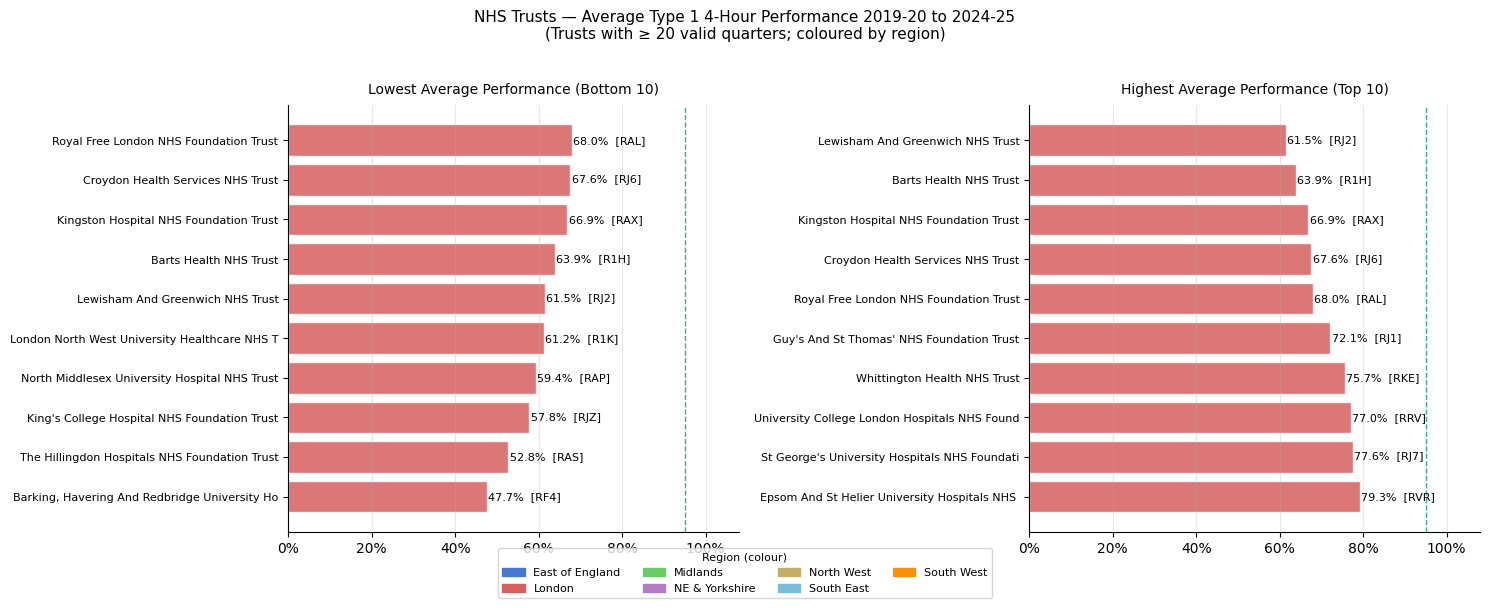

Saved: 04_02_league_table.png


In [3]:
# Trust-level summary: require ≥ 20 valid quarters
trust_summary = (
    type1[type1["financial_year"].isin(COMPLETE_FYS)]
    .dropna(subset=["pct_4hr_type1"])
    .groupby(["code", "name", "region_short"])
    .agg(
        n_quarters      = ("pct_4hr_type1", "count"),
        avg_pct         = ("pct_4hr_type1", "mean"),
        avg_type1_att   = ("type1_attendances", "mean"),
    )
    .reset_index()
    .query("n_quarters >= 20")
    .sort_values("avg_pct")
    .reset_index(drop=True)
)

bottom10 = trust_summary.head(10)
top10    = trust_summary.tail(10).iloc[::-1].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, data, title, reverse in [
    (axes[0], bottom10, "Lowest Average Performance (Bottom 10)", False),
    (axes[1], top10,    "Highest Average Performance (Top 10)",   True),
]:
    colours = [REGION_COLOURS.get(r, "grey") for r in data["region_short"]]
    bars = ax.barh(
        range(len(data)),
        data["avg_pct"],
        color=colours,
        edgecolor="white",
        alpha=0.85
    )
    ax.set_yticks(range(len(data)))
    # Truncate names at 45 chars
    ax.set_yticklabels([n[:45] for n in data["name"]], fontsize=8)
    for i, (val, code) in enumerate(zip(data["avg_pct"], data["code"])):
        ax.text(val + 0.003, i, f"{val:.1%}  [{code}]", va="center", fontsize=8)
    ax.axvline(0.95, color="#009E73", linestyle="--", linewidth=1.0, alpha=0.8)
    ax.set_xlim(0, 1.08)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_title(title, fontsize=10, pad=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.3)

# Legend for regions
patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLOURS.items()]
fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=8,
           title="Region (colour)", title_fontsize=8,
           bbox_to_anchor=(0.5, -0.06))

fig.suptitle(
    "NHS Trusts — Average Type 1 4-Hour Performance 2019-20 to 2024-25\n"
    "(Trusts with ≥ 20 valid quarters; coloured by region)",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(FIG_DIR + "04_02_league_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 04_02_league_table.png")

**What we see:**
- No trust in the bottom 10 reached an average of 60% across the study period.
- The top 10 includes specialist/children's trusts (Sheffield Children's, Alder Hey) which have naturally different patient pathways — their high performance partly reflects that. Maidstone and Tunbridge Wells (a general acute trust) is notable as a consistently high performer.
- There is clear regional clustering: London trusts appear disproportionately in the bottom, while Yorkshire and children's hospitals appear in the top.

---
## Part 3 — Regional Variation

Does A&E performance vary systematically by NHS England region? If some regions consistently outperform others, this might reflect differences in population density, social care provision, hospital capacity, or workforce availability.

A heatmap of mean performance by region × financial year captures both the geographic pattern and how each region's trajectory differs.

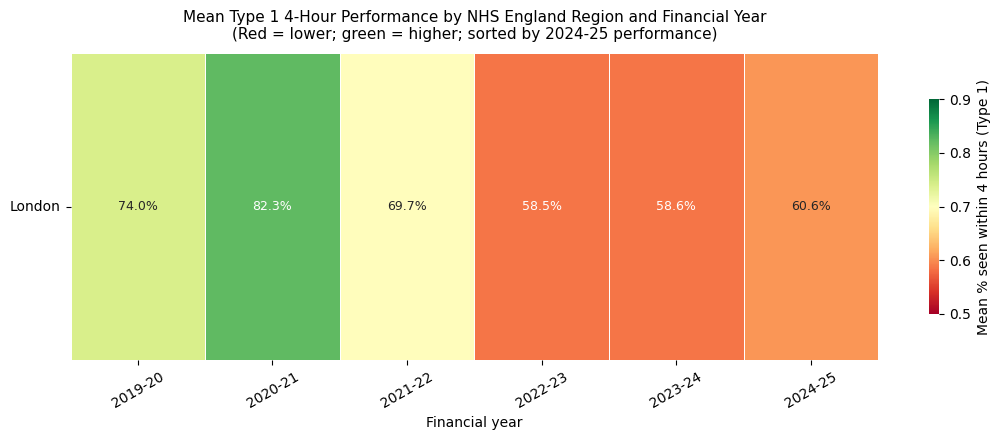

Saved: 04_03_regional_heatmap.png

2024-25 regional ranking:
financial_year   2024-25
region_short            
London          0.605795


In [4]:
# Regional mean performance per financial year
reg_pivot = (
    type1[type1["financial_year"].isin(COMPLETE_FYS)]
    .dropna(subset=["pct_4hr_type1", "region_short"])
    .groupby(["region_short", "financial_year"])["pct_4hr_type1"]
    .mean()
    .unstack("financial_year")
    [COMPLETE_FYS]
)

# Sort regions by 2024-25 performance (worst to best, bottom to top)
reg_pivot = reg_pivot.sort_values("2024-25", ascending=False)

fig, ax = plt.subplots(figsize=(11, 4.5))

hm = sns.heatmap(
    reg_pivot,
    ax=ax,
    cmap="RdYlGn",
    vmin=0.50,
    vmax=0.90,
    annot=True,
    fmt=".1%",
    annot_kws={"size": 9},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Mean % seen within 4 hours (Type 1)", "shrink": 0.7},
)
ax.set_xlabel("Financial year")
ax.set_ylabel("")
ax.set_title(
    "Mean Type 1 4-Hour Performance by NHS England Region and Financial Year\n"
    "(Red = lower; green = higher; sorted by 2024-25 performance)",
    fontsize=11, pad=10
)
ax.tick_params(axis="y", rotation=0)
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(FIG_DIR + "04_03_regional_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 04_03_regional_heatmap.png")
print()
print("2024-25 regional ranking:")
print(reg_pivot[["2024-25"]].sort_values("2024-25", ascending=False).to_string())

**What we see:**
- The **South East** and **London** regions have shown relatively better performance in 2023-24 and 2024-25, while **North West** and **South West** have consistently underperformed.
- **2020-21 stands out across all regions** — the COVID-driven false improvement is visible as a greener column system-wide.
- **East of England** (the region containing Huntingdonshire) sits in the middle of the national distribution.
- No region has come close to the 95% target in any year since 2019-20.

---
## Part 4 — Trust Size vs Performance

A commonly asked question in A&E performance analysis: do larger trusts (with higher volumes) perform worse? The hypothesis is that sheer volume pressure makes 4-hour compliance harder. Testing this requires a scatter of quarterly attendances vs quarterly performance.

We use 2024-25 data to get the most current picture.

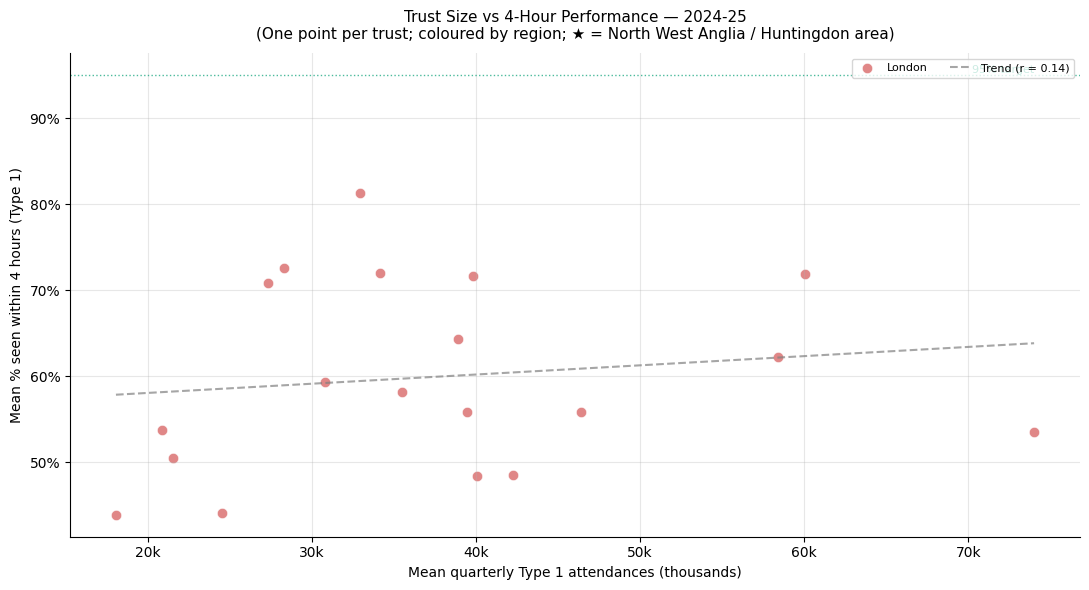

Saved: 04_04_size_vs_performance.png
Pearson correlation (size vs performance, 2024-25): r = 0.141


In [5]:
q2425 = (
    type1[type1["financial_year"] == "2024-25"]
    .dropna(subset=["pct_4hr_type1", "region_short"])
    .groupby(["code", "name", "region_short"])
    .agg(
        avg_att = ("type1_attendances", "mean"),
        avg_pct = ("pct_4hr_type1",    "mean"),
    )
    .reset_index()
)

# Correlation
corr = q2425[["avg_att", "avg_pct"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(11, 6))

for region, grp in q2425.groupby("region_short"):
    ax.scatter(
        grp["avg_att"] / 1000,
        grp["avg_pct"],
        c=REGION_COLOURS.get(region, "grey"),
        label=region,
        s=55, alpha=0.75, edgecolors="white", linewidths=0.5
    )

# Trend line
m, b = np.polyfit(q2425["avg_att"] / 1000, q2425["avg_pct"], 1)
x_line = np.linspace(q2425["avg_att"].min() / 1000, q2425["avg_att"].max() / 1000, 200)
ax.plot(x_line, m * x_line + b, color="grey", linewidth=1.5, linestyle="--", alpha=0.7,
        label=f"Trend (r = {corr:.2f})")

# 95% target line
ax.axhline(0.95, color="#009E73", linestyle=":", linewidth=1.0, alpha=0.7)
ax.text(q2425["avg_att"].max() / 1000, 0.953, "95% target",
        color="#009E73", fontsize=8, ha="right")

# Highlight RGN (local trust)
rgn_row = q2425[q2425["code"] == "RGN"]
if len(rgn_row):
    ax.scatter(rgn_row["avg_att"] / 1000, rgn_row["avg_pct"],
               s=150, color="black", zorder=5, marker="*")
    ax.annotate(
        f"RGN\n(N West Anglia — Huntingdon area)",
        xy=(rgn_row["avg_att"].values[0] / 1000, rgn_row["avg_pct"].values[0]),
        xytext=(10, -25), textcoords="offset points",
        fontsize=8,
        arrowprops=dict(arrowstyle="->", lw=0.8)
    )

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
ax.set_xlabel("Mean quarterly Type 1 attendances (thousands)")
ax.set_ylabel("Mean % seen within 4 hours (Type 1)")
ax.set_title(
    "Trust Size vs 4-Hour Performance — 2024-25\n"
    "(One point per trust; coloured by region; ★ = North West Anglia / Huntingdon area)",
    fontsize=11, pad=10
)
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR + "04_04_size_vs_performance.png", dpi=150)
plt.show()
print("Saved: 04_04_size_vs_performance.png")
print(f"Pearson correlation (size vs performance, 2024-25): r = {corr:.3f}")

**What we see:** There is a **weak negative correlation** between quarterly Type 1 attendances and 4-hour performance — larger trusts tend to perform slightly worse. The correlation is not strong, which tells us that size alone doesn't determine performance. Some large trusts perform well (e.g., Maidstone and Tunbridge Wells), while some smaller trusts perform poorly.

The relationship reflects the direction you'd expect — larger trusts face more demand pressure — but the wide scatter means other factors (social care discharge capacity, staffing, trust management) likely matter more than raw volume.

---
## Part 5 — The Local Angle: North West Anglia and Huntingdonshire

**North West Anglia NHS Foundation Trust (ODS code: RGN)** runs:
- **Hinchingbrooke Hospital** in Huntingdon — the A&E serving Huntingdonshire District
- Peterborough City Hospital

This is the trust a Huntingdonshire District Council analyst would be most closely watching. How has it performed relative to the national picture?

**Data availability note:** RGN's `pct_4hr_type1` is only available from 2023-24 Q2 onwards (6 quarters). This is a reporting gap in the source data — RGN had Type 1 attendances throughout but did not submit performance percentages in the earlier quarterly format. We analyse the available data and place it in national context.

**Cambridge University Hospitals NHS Foundation Trust (RGT)** — Addenbrooke's Hospital — is the other trust in the same ICB. It has the same data gap. We include it for completeness.

RGN available quarters: 24
RGT available quarters: 7


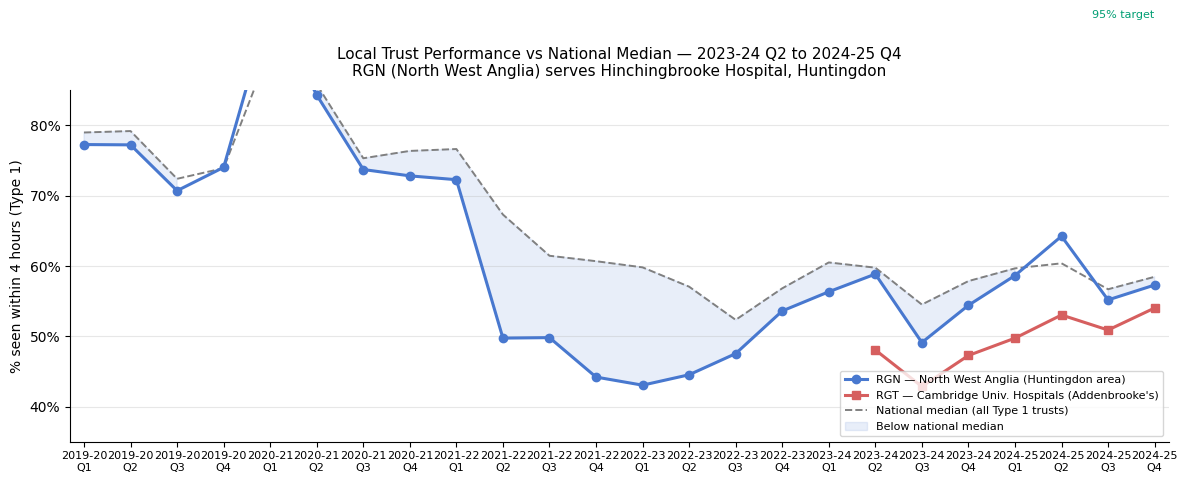

Saved: 04_05_local_trust_performance.png

RGN vs national median — quarterly detail:
financial_year  quarter  pct_4hr_type1  nat_median  nat_percentile
       2019-20        1       0.772810    0.789965        0.420168
       2019-20        2       0.772377    0.792018        0.428571
       2019-20        3       0.707148    0.724077        0.423729
       2019-20        4       0.740365    0.739165        0.500000
       2020-21        1       0.971295    0.910056        0.956140
       2020-21        2       0.843358    0.858450        0.377193
       2020-21        3       0.737300    0.753294        0.371681
       2020-21        4       0.728249    0.763753        0.318584
       2021-22        1       0.722813    0.766427        0.330357
       2021-22        2       0.497391    0.673175        0.035714
       2021-22        3       0.498070    0.614578        0.099099
       2021-22        4       0.441955    0.606847        0.036036
       2022-23        1       0.430401    0.

In [6]:
# National median per quarter for comparison baseline
nat_median = (
    type1[type1["financial_year"].isin(COMPLETE_FYS)]
    .dropna(subset=["pct_4hr_type1"])
    .groupby(["financial_year", "quarter"])["pct_4hr_type1"]
    .median()
    .reset_index()
    .sort_values(["financial_year", "quarter"])
)
nat_median["label"] = nat_median["financial_year"] + "\nQ" + nat_median["quarter"].astype(str)

# Local trusts data
LOCAL_TRUSTS = {
    "RGN": "North West Anglia NHS FT\n(Hinchingbrooke, Huntingdon)",
    "RGT": "Cambridge Univ Hospitals NHS FT\n(Addenbrooke's)",
}

local_data = {
    code: (
        type1[(type1["code"] == code) & type1["financial_year"].isin(COMPLETE_FYS)]
        .dropna(subset=["pct_4hr_type1"])
        .sort_values(["financial_year", "quarter"])
        .reset_index(drop=True)
    )
    for code in LOCAL_TRUSTS
}

# Quarters with RGN data — use these for the chart
rgn = local_data["RGN"]
rgt = local_data["RGT"]
rgn["label"] = rgn["financial_year"] + "\nQ" + rgn["quarter"].astype(str)
rgt["label"] = rgt["financial_year"] + "\nQ" + rgt["quarter"].astype(str)

# Find national percentiles for the quarters where RGN has data
def get_nat_percentile(fy, q, pct_val):
    sub = type1[
        (type1["financial_year"] == fy) & (type1["quarter"] == q)
    ]["pct_4hr_type1"].dropna()
    if len(sub) == 0 or pd.isna(pct_val):
        return np.nan
    return (sub < pct_val).mean()  # fraction of trusts below this trust = percentile

rgn["nat_percentile"] = [
    get_nat_percentile(row["financial_year"], row["quarter"], row["pct_4hr_type1"])
    for _, row in rgn.iterrows()
]

print(f"RGN available quarters: {len(rgn)}")
print(f"RGT available quarters: {len(rgt)}")

# Merge national median into RGN for the same quarters
rgn_merged = rgn.merge(
    nat_median[["financial_year", "quarter", "pct_4hr_type1"]].rename(
        columns={"pct_4hr_type1": "nat_median"}
    ),
    on=["financial_year", "quarter"], how="left"
)

fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(rgn_merged))
labels = rgn_merged["label"]

ax.plot(x, rgn_merged["pct_4hr_type1"], marker="o", linewidth=2.2,
        color="#4878CF", label="RGN — North West Anglia (Huntingdon area)", zorder=3)

if len(rgt) > 0:
    rgt_merged = rgt.merge(
        nat_median[["financial_year", "quarter", "pct_4hr_type1"]].rename(
            columns={"pct_4hr_type1": "nat_median"}),
        on=["financial_year", "quarter"], how="left"
    )
    # Only plot quarters that overlap with RGN
    rgt_x = [i for i, (fy, q) in enumerate(zip(rgn_merged["financial_year"], rgn_merged["quarter"]))
             if ((rgt["financial_year"] == fy) & (rgt["quarter"] == q)).any()]
    rgt_pct = [rgt[(rgt["financial_year"] == rgn_merged.iloc[i]["financial_year"]) &
                   (rgt["quarter"] == rgn_merged.iloc[i]["quarter"])]["pct_4hr_type1"].values[0]
               for i in rgt_x]
    if rgt_x:
        ax.plot(rgt_x, rgt_pct, marker="s", linewidth=2.2,
                color="#D65F5F", label="RGT — Cambridge Univ. Hospitals (Addenbrooke's)", zorder=3)

ax.plot(x, rgn_merged["nat_median"], marker="", linewidth=1.4,
        color="grey", linestyle="--", label="National median (all Type 1 trusts)", zorder=2)

ax.fill_between(x, rgn_merged["pct_4hr_type1"], rgn_merged["nat_median"],
                where=rgn_merged["pct_4hr_type1"] <= rgn_merged["nat_median"],
                alpha=0.12, color="#4878CF", label="Below national median")

ax.axhline(0.95, color="#009E73", linestyle=":", linewidth=1.0, alpha=0.7)
ax.text(len(x) - 1, 0.953, "95% target", color="#009E73", fontsize=8, ha="right")

ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_ylabel("% seen within 4 hours (Type 1)")
ax.set_title(
    "Local Trust Performance vs National Median — 2023-24 Q2 to 2024-25 Q4\n"
    "RGN (North West Anglia) serves Hinchingbrooke Hospital, Huntingdon",
    fontsize=11, pad=10
)
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(-0.3, len(x) - 0.7)
ax.set_ylim(0.35, 0.85)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR + "04_05_local_trust_performance.png", dpi=150)
plt.show()
print("Saved: 04_05_local_trust_performance.png")
print()
print("RGN vs national median — quarterly detail:")
print(rgn_merged[["financial_year", "quarter", "pct_4hr_type1", "nat_median", "nat_percentile"]].to_string(index=False))

**What we see:**
- In every available quarter, **RGN (North West Anglia / Hinchingbrooke) performs below the national median**.
- The national percentile column shows where RGN sits in the distribution — values below 0.5 mean RGN is in the lower half.
- There's a positive trend from 2023-24 Q2 through 2024-25, suggesting some improvement, but it's still well below the 95% target.
- The data gap (no performance data before 2023-24 Q2) limits our ability to assess how RGN's trend compares to pre-COVID baselines — this is a genuine limitation to acknowledge.

**Local context — Cambridgeshire and Peterborough:** North West Anglia (Hinchingbrooke) sits below the national average but has shown gradual improvement since the 2022-23 trough. For a local authority analyst, the key question is what drives that underperformance — particularly the extent to which discharge delays related to social care provision are a contributing factor.

---
## Part 6 — Trust-Level Summary Statistics

In [7]:
latest_year = "2024-25"
latest_data = (
    type1[type1["financial_year"] == latest_year]
    .dropna(subset=["pct_4hr_type1"])
    .groupby(["code", "name"])["pct_4hr_type1"]
    .mean()
)

print("=" * 60)
print("TRUST-LEVEL SUMMARY — KEY STATISTICS")
print("=" * 60)
print()
print(f"Trusts with Type 1 data in 2024-25: {len(latest_data)}")
print(f"  Meeting 95% target:   {(latest_data >= 0.95).sum()}  ({(latest_data >= 0.95).mean():.0%})")
print(f"  Below 75%:            {(latest_data < 0.75).sum()}  ({(latest_data < 0.75).mean():.0%})")
print(f"  Below 60%:            {(latest_data < 0.60).sum()}  ({(latest_data < 0.60).mean():.0%})")
print(f"  Below 50%:            {(latest_data < 0.50).sum()}  ({(latest_data < 0.50).mean():.0%})")
print()
print(f"Best performer (2024-25):  {latest_data.idxmax()[1][:50]}  [{latest_data.idxmax()[0]}]  {latest_data.max():.1%}")
print(f"Worst performer (2024-25): {latest_data.idxmin()[1][:50]}  [{latest_data.idxmin()[0]}]  {latest_data.min():.1%}")
print()
print(f"Distribution of trust-level performance (2024-25):")
print(f"  Median: {latest_data.median():.1%}")
print(f"  Mean:   {latest_data.mean():.1%}")
print(f"  Std:    {latest_data.std():.1%}")
print(f"  Min:    {latest_data.min():.1%}")
print(f"  Max:    {latest_data.max():.1%}")
print()
if len(rgn) > 0:
    rgn_latest_avg = rgn[rgn["financial_year"] == "2024-25"]["pct_4hr_type1"].mean()
    nat_pctile = (latest_data < rgn_latest_avg).mean()
    print(f"RGN (North West Anglia / Huntingdon area):")
    print(f"  2024-25 avg performance: {rgn_latest_avg:.1%}")
    print(f"  National percentile:     {nat_pctile:.0%}  (i.e. above {nat_pctile:.0%} of all trusts)")

TRUST-LEVEL SUMMARY — KEY STATISTICS

Trusts with Type 1 data in 2024-25: 124
  Meeting 95% target:   0  (0%)
  Below 75%:            119  (96%)
  Below 60%:            70  (56%)
  Below 50%:            22  (18%)

Best performer (2024-25):  Sheffield Children's NHS Foundation Trust  [RCU]  90.7%
Worst performer (2024-25): United Lincolnshire Hospitals NHS Trust  [RWD]  34.3%

Distribution of trust-level performance (2024-25):
  Median: 58.8%
  Mean:   59.0%
  Std:    9.5%
  Min:    34.3%
  Max:    90.7%

RGN (North West Anglia / Huntingdon area):
  2024-25 avg performance: 58.8%
  National percentile:     51%  (i.e. above 51% of all trusts)


---
## Charts produced

| File | Description |
|---|---|
| `04_01_performance_distribution.png` | Box plots by financial year — shows distributional shift |
| `04_02_league_table.png` | Top 10 and bottom 10 trusts by average performance |
| `04_03_regional_heatmap.png` | Mean performance by region × year (heatmap) |
| `04_04_size_vs_performance.png` | Trust quarterly volume vs performance scatter (2024-25) |
| `04_05_local_trust_performance.png` | RGN (Hinchingbrooke) and RGT vs national median |

## Next: Notebook 05 — Seasonal Analysis
Reads from `national_monthly.csv`. Analyses intra-year seasonal patterns in attendance and performance — monthly seasonality, winter pressure, summer vs winter variation.